In [ ]:
import time
import numpy as np
import matplotlib.pyplot as plt
from numba import cuda
import pandas as pd

In [ ]:
def vector_sum_cpu(vector):
    result = 0.0
    for i in range(len(vector)):
        result += vector[i]
    return result

@cuda.jit
def vector_sum_gpu_kernel(vector, result):
    temp = cuda.shared.array(256, dtype=np.float32)
    idx = cuda.grid(1)

    if idx < vector.size:
        temp[cuda.threadIdx.x] = vector[idx]
    else:
        temp[cuda.threadIdx.x] = 0.0

    cuda.syncthreads()

    i = cuda.blockDim.x // 2
    while i > 0:
        if cuda.threadIdx.x < i:
            temp[cuda.threadIdx.x] += temp[cuda.threadIdx.x + i]
        cuda.syncthreads()
        i //= 2

    if cuda.threadIdx.x == 0:
        cuda.atomic.add(result, 0, temp[0])

def vector_sum_gpu(vector):
    result = np.zeros(1, dtype=np.float32)
    d_result = cuda.to_device(result)
    d_vector = cuda.to_device(vector)

    threads_per_block = 256
    blocks_per_grid = (vector.size + (threads_per_block - 1)) // threads_per_block
    vector_sum_gpu_kernel[blocks_per_grid, threads_per_block](d_vector, d_result)
    cuda.synchronize()
    return d_result.copy_to_host()[0]

def measure_time(vector_size):
    vector = np.random.rand(vector_size).astype(np.float32)

    # CPU измерение
    start_time = time.perf_counter()
    cpu_result = vector_sum_cpu(vector)
    cpu_time = time.perf_counter() - start_time

    _ = vector_sum_gpu(vector)

    # GPU измерение
    start_time = time.perf_counter()
    gpu_result = vector_sum_gpu(vector)
    gpu_time = time.perf_counter() - start_time

    speedup = cpu_time / gpu_time
    return cpu_time, gpu_time, speedup

In [ ]:
vector_sizes = [1000, 5000, 10000, 50000, 100000, 500000, 1000000]
results = []

print("Размер вектора  Время на CPU (с)  Время на GPU (с)  Ускорение")

for size in vector_sizes:
    cpu_time, gpu_time, speedup = measure_time(size)
    results.append([size, cpu_time, gpu_time, speedup])
    print(f"{size:>14}  {cpu_time:>16.6f}  {gpu_time:>16.6f}  {speedup:>10.2f}")

Размер вектора  Время на CPU (с)  Время на GPU (с)  Ускорение
          1000          0.000456          0.000905        0.50
          5000          0.003562          0.000820        4.35
         10000          0.007681          0.001356        5.66
         50000          0.013515          0.000574       23.55
        100000          0.015345          0.000625       24.54
        500000          0.080610          0.001542       52.27
       1000000          0.166332          0.001684       98.80


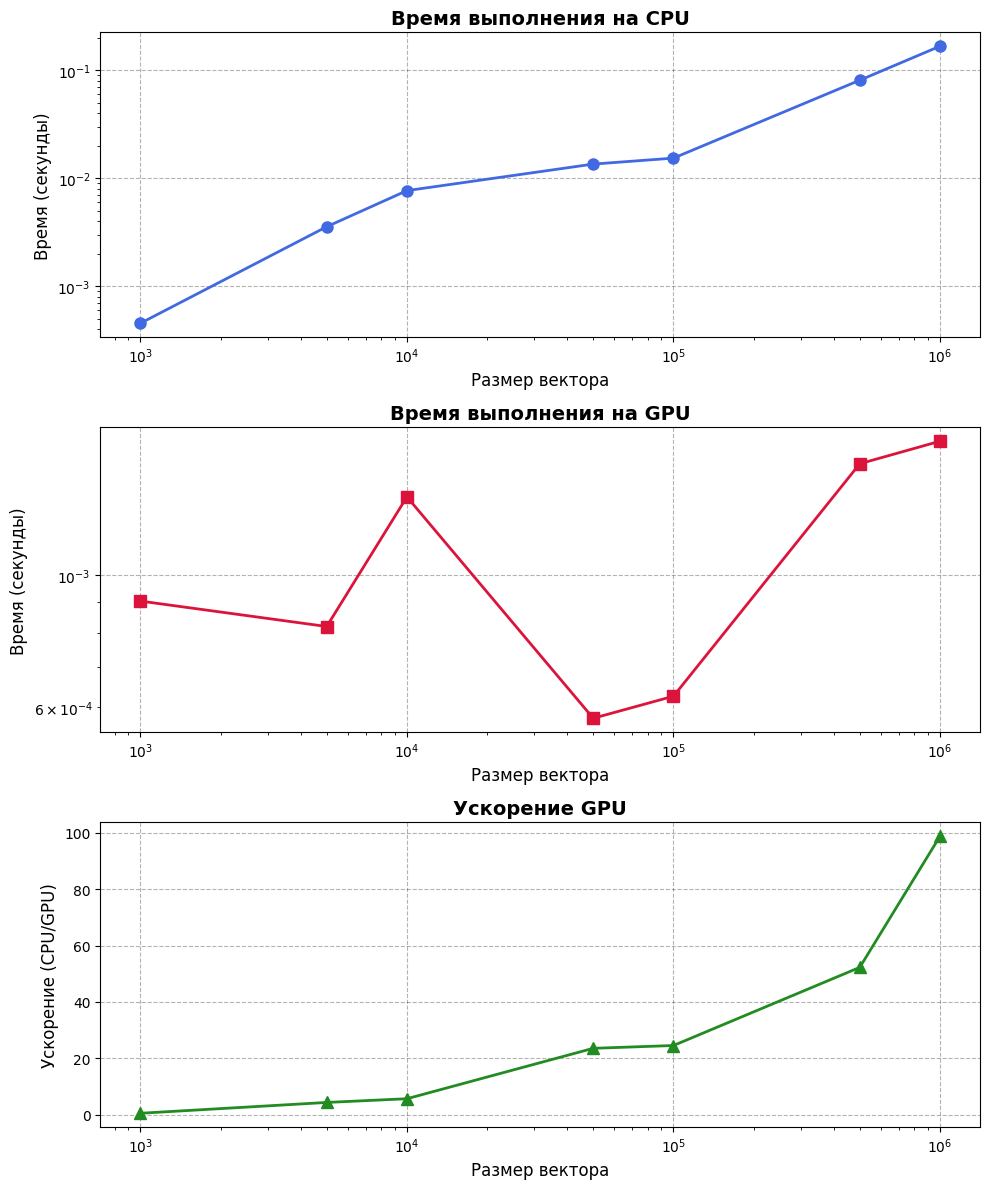

In [ ]:
df_results = pd.DataFrame(results, columns=['Размер вектора', 'Время на CPU (с)', 'Время на GPU (с)', 'Ускорение'])

plt.style.use('default')
plt.figure(figsize=(10, 12))

# График 1: Время на CPU
plt.subplot(3, 1, 1)
plt.plot(df_results["Размер вектора"], df_results["Время на CPU (с)"], 'o-', color='royalblue', linewidth=2, markersize=8)
plt.xscale("log")
plt.yscale("log")
plt.xlabel("Размер вектора", fontsize=12)
plt.ylabel("Время (секунды)", fontsize=12)
plt.title("Время выполнения на CPU", fontsize=14, fontweight='bold')
plt.grid(True, color='black', alpha=0.3, linestyle='--')
plt.gca().set_facecolor('white')

# График 2: Время на GPU
plt.subplot(3, 1, 2)
plt.plot(df_results["Размер вектора"], df_results["Время на GPU (с)"], 's-', color='crimson', linewidth=2, markersize=8)
plt.xscale("log")
plt.yscale("log")
plt.xlabel("Размер вектора", fontsize=12)
plt.ylabel("Время (секунды)", fontsize=12)
plt.title("Время выполнения на GPU", fontsize=14, fontweight='bold')
plt.grid(True, color='black', alpha=0.3, linestyle='--')
plt.gca().set_facecolor('white')

# График 3: Ускорение
plt.subplot(3, 1, 3)
plt.plot(df_results["Размер вектора"], df_results["Ускорение"], '^-', color='forestgreen', linewidth=2, markersize=8)
plt.xscale("log")
plt.xlabel("Размер вектора", fontsize=12)
plt.ylabel("Ускорение (CPU/GPU)", fontsize=12)
plt.title("Ускорение GPU", fontsize=14, fontweight='bold')
plt.grid(True, color='black', alpha=0.3, linestyle='--')
plt.gca().set_facecolor('white')

plt.tight_layout()
plt.show()